# CellPert — how far apart the two datasets sit, before and after the encoder

Everything here rests on one object, the encoder's graph-level mean `graph_mu`, taken
from the released checkpoint. Two statistics are computed for every Mini Tahoe plate
against LINCS, once in the raw 965-gene space and once in the 100-dimensional latent.

* **KS statistic**, the two-sample Kolmogorov-Smirnov statistic between the two datasets,
  computed per dimension and averaged over dimensions.
* **Silhouette score** with `metric='cosine'`, labelling each cell by its dataset.

Lower means the two datasets sit closer together.

`SUBSAMPLE` at the top of the setup cell controls the cost. Set it to `None` to use every
cell, which is what the published analysis does and which takes hours; the default keeps
it to a few thousand cells per dataset so the notebook runs in minutes. `umap-learn` is
needed for the last section and is not part of `environment.yml`.


In [1]:
import sys
sys.path.insert(0, './src')

import numpy as np
import scanpy as sc
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoLoader

from dataset import ChunkedGeneGraphDataset
from model import GINVAE

# None uses every cell, as the published analysis does. An integer caps how many cells
# are drawn from each dataset, which is what makes this notebook run in minutes.
SUBSAMPLE = 3000
BATCH = 256

LINCS_PATH = './data/lincs/merged_all_965_with_morgan.h5ad'
TAHOE_PATH = './data/minitahoe/p%d_with_morgan.h5ad'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GINVAE(input_dim=1, hidden_dim=300, latent_dim=100, num_layers=2).to(device)
model.load_state_dict(torch.load('./src/best_gin_vae_model_node_level.pth',
                                 map_location=device))
model.eval()

# One graph, shared by every plate: the same 965 genes and the same STRING edges, so it
# is built once rather than rebuilt per plate.
_probe = ChunkedGeneGraphDataset(h5ad_paths=[TAHOE_PATH % 1], split='test',
                                 chunk_size=10000, auto_build_graph=True,
                                 species=9606, required_score=700)
EDGE_INDEX = _probe[0].edge_index
print('graph edges:', EDGE_INDEX.shape[1])

to_dense = lambda X: np.asarray(X.todense() if hasattr(X, 'todense') else X,
                                dtype=np.float32)


def load(path, seed):
    """Raw matrix and obs for one file, subsampled only when SUBSAMPLE is set."""
    ad = sc.read_h5ad(path)
    if SUBSAMPLE is None or ad.n_obs <= SUBSAMPLE:
        idx = np.arange(ad.n_obs)
    else:
        idx = np.random.default_rng(seed).choice(ad.n_obs, size=SUBSAMPLE, replace=False)
    return to_dense(ad.X)[idx], ad.obs.iloc[idx]


def encode(X):
    """Encoder graph-level mean for a matrix of cells by genes."""
    out = []
    with torch.no_grad():
        for s in range(0, len(X), BATCH):
            chunk = [Data(x=torch.tensor(X[i], dtype=torch.float).unsqueeze(1),
                          edge_index=EDGE_INDEX)
                     for i in range(s, min(s + BATCH, len(X)))]
            b = next(iter(GeoLoader(chunk, batch_size=len(chunk), shuffle=False))).to(device)
            _, _, gmu, _ = model.encoder(b.x, b.edge_index, b.batch)
            out.append(gmu.cpu().numpy())
    return np.concatenate(out).astype(np.float32)


LX, _ = load(LINCS_PATH, 0)
LZ = encode(LX)
print('LINCS  raw', LX.shape, ' latent', LZ.shape)


Found 4 chunks with 39546 total samples


graph edges: 13498


LINCS  raw (3000, 965)  latent (3000, 100)


## Plate by plate

One dumbbell per plate and per statistic: the circle is the raw space, the triangle the
latent space. The two statistics are drawn side by side so their ranges do not overlap.


P1   KS 0.9986 -> 0.6843   silhouette 0.6803 -> 0.3542


P2   KS 0.9994 -> 0.7793   silhouette 0.8059 -> 0.6483


P3   KS 0.9997 -> 0.8415   silhouette 0.7455 -> 0.7893


P4   KS 0.9993 -> 0.7668   silhouette 0.8611 -> 0.6093


P5   KS 0.9997 -> 0.8700   silhouette 0.7410 -> 0.8266


...

P11  KS 0.9991 -> 0.8135   silhouette 0.8719 -> 0.7367


P12  KS 0.9994 -> 0.8585   silhouette 0.8044 -> 0.8408


P13  KS 0.9995 -> 0.8659   silhouette 0.7823 -> 0.8565


P14  KS 0.9997 -> 0.8752   silhouette 0.7536 -> 0.8417


means  KS 0.9994 -> 0.8280   silhouette 0.7842 -> 0.7484


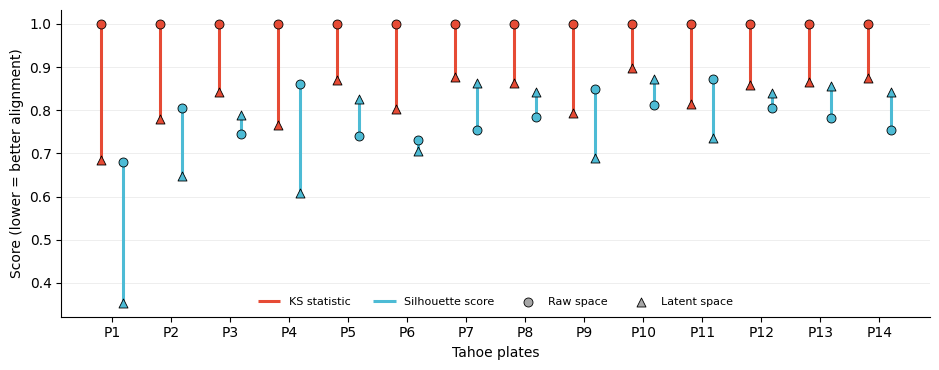

In [2]:
from scipy.stats import ks_2samp
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


def ks_mean(A, B):
    return float(np.mean([ks_2samp(A[:, j], B[:, j])[0] for j in range(A.shape[1])]))


def sil(A, B):
    M = np.concatenate([A, B])
    lab = np.array([0] * len(A) + [1] * len(B))
    return float(silhouette_score(M, lab, metric='cosine'))


rows = []
for p in range(1, 15):
    TX_p, _ = load(TAHOE_PATH % p, p)
    TZ_p = encode(TX_p)
    rows.append({'plate': p,
                 'ks_raw': ks_mean(LX, TX_p), 'ks_latent': ks_mean(LZ, TZ_p),
                 'sil_raw': sil(LX, TX_p), 'sil_latent': sil(LZ, TZ_p)})
    print('P%-2d  KS %.4f -> %.4f   silhouette %.4f -> %.4f'
          % (p, rows[-1]['ks_raw'], rows[-1]['ks_latent'],
             rows[-1]['sil_raw'], rows[-1]['sil_latent']), flush=True)

print('means  KS %.4f -> %.4f   silhouette %.4f -> %.4f'
      % (np.mean([r['ks_raw'] for r in rows]), np.mean([r['ks_latent'] for r in rows]),
         np.mean([r['sil_raw'] for r in rows]), np.mean([r['sil_latent'] for r in rows])))

x = np.arange(len(rows))
OFF = 0.19
fig, ax = plt.subplots(figsize=(9.5, 3.8))
for dx, kr, kl, color, name in ((-OFF, 'ks_raw', 'ks_latent', '#E64B35', 'KS statistic'),
                                (+OFF, 'sil_raw', 'sil_latent', '#4DBBD5', 'Silhouette score')):
    hi = np.array([r[kr] for r in rows])
    lo = np.array([r[kl] for r in rows])
    ax.vlines(x + dx, np.minimum(lo, hi), np.maximum(lo, hi), color=color, lw=2.2,
              zorder=1, label=name)
    ax.scatter(x + dx, hi, s=42, facecolor=color, edgecolor='black', lw=0.6, zorder=2)
    ax.scatter(x + dx, lo, s=42, marker='^', facecolor=color, edgecolor='black',
               lw=0.6, zorder=2)
ax.scatter([], [], s=42, facecolor='0.65', edgecolor='black', lw=0.6, label='Raw space')
ax.scatter([], [], s=42, marker='^', facecolor='0.65', edgecolor='black', lw=0.6,
           label='Latent space')
ax.set_xticks(x); ax.set_xticklabels(['P%d' % r['plate'] for r in rows])
ax.set_xlabel('Tahoe plates')
ax.set_ylabel('Score (lower = better alignment)')
ax.legend(frameon=False, ncol=4, fontsize=8, loc='lower center')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, lw=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


## The same two spaces drawn with UMAP

The top row is the raw 965-gene space and the bottom row the latent space, each coloured
three ways: by dataset, by Mini Tahoe cell line, and by perturbation state. LINCS is drawn
in grey in the second and third columns so the Mini Tahoe structure reads against it.


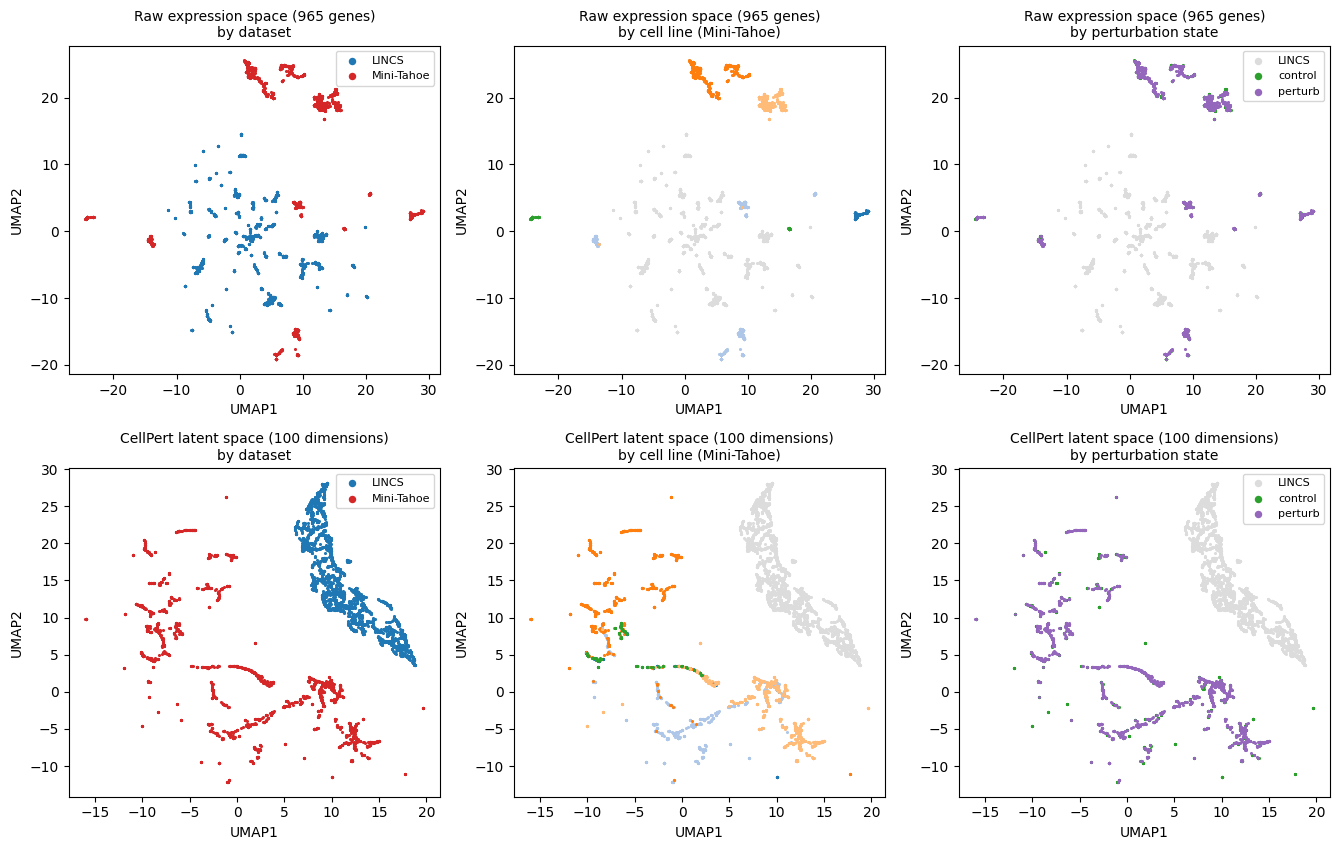

In [3]:
import umap
import matplotlib.pyplot as plt

TX, tobs = load(TAHOE_PATH % 1, 1)
TZ = encode(TX)
cell_line = tobs['cell_type'].astype(str).values
condition = tobs['condition'].astype(str).values
dataset_lab = np.array(['LINCS'] * len(LX) + ['Mini-Tahoe'] * len(TX))

emb = {}
for space, (A, B) in (('raw', (LX, TX)), ('latent', (LZ, TZ))):
    emb[space] = umap.UMAP(n_neighbors=15, min_dist=0.1,
                           random_state=0).fit_transform(np.concatenate([A, B]))

GREY = '#DCDCDC'
n_l = len(LX)
lines = sorted(set(cell_line))
line_color = {c: plt.get_cmap('tab20')(i % 20) for i, c in enumerate(lines)}

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.6))
for row, space in enumerate(('raw', 'latent')):
    E = emb[space]
    title = ('Raw expression space (965 genes)' if space == 'raw'
             else 'CellPert latent space (100 dimensions)')

    ax = axes[row, 0]
    for k, c in (('LINCS', '#1F77B4'), ('Mini-Tahoe', '#D62728')):
        m = dataset_lab == k
        ax.scatter(E[m, 0], E[m, 1], s=5, c=c, linewidths=0, label=k)
    ax.legend(fontsize=8, markerscale=2.4, frameon=True)
    ax.set_title(title + '\nby dataset', fontsize=10)

    ax = axes[row, 1]
    ax.scatter(E[:n_l, 0], E[:n_l, 1], s=5, c=GREY, linewidths=0, zorder=1)
    for c in lines:
        m = np.zeros(len(E), bool); m[n_l:] = cell_line == c
        ax.scatter(E[m, 0], E[m, 1], s=5, color=line_color[c], linewidths=0, zorder=2)
    ax.set_title(title + '\nby cell line (Mini-Tahoe)', fontsize=10)

    ax = axes[row, 2]
    ax.scatter(E[:n_l, 0], E[:n_l, 1], s=5, c=GREY, linewidths=0, label='LINCS', zorder=1)
    for k, c in (('control', '#2CA02C'), ('perturb', '#9467BD')):
        m = np.zeros(len(E), bool); m[n_l:] = condition == k
        ax.scatter(E[m, 0], E[m, 1], s=5, c=c, linewidths=0, label=k, zorder=2)
    ax.legend(fontsize=8, markerscale=2.4, frameon=True)
    ax.set_title(title + '\nby perturbation state', fontsize=10)

for ax in axes.ravel():
    ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
plt.tight_layout(); plt.show()
